<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B02%5D%20-%20Modelos%20Supervisados%20Lineales/Primer_Modelo_Churn_Marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA Predictiva en Marketing: Churn y decisiones
**Notebook práctico para apoyar la dinámica “¿a quién damos descuento?”**  

> Objetivo: que puedas **ver, tocar y usar** un modelo predictivo sin necesidad de saber Machine Learning.  
> Tú decides **qué acción tomar** con cada cliente; el modelo solo te da una **probabilidad**.


## 1) Contexto

Imagina este escenario:

- Tienes un eCommerce con miles de clientes.
- No puedes dar descuentos a todos (porque el margen no es infinito).
- Quieres **priorizar** a los clientes con mayor riesgo de irse (**churn**).

En clase primero haremos una predicción **manual** con una tabla pequeña (6 clientes).  
Después, aquí, veremos cómo un modelo **escala** esa decisión a miles de clientes.



## 2) Qué vas a aprender hoy

1. Qué es un problema de **clasificación** (churn: *sí/no*).
2. Cómo se entrena un modelo simple (sin fórmulas).
3. Qué es una **matriz de confusión** y por qué importa en negocio.
4. Cómo usar un modelo para predecir churn en clientes nuevos.
5. Qué es un **umbral (threshold)** y por qué **lo decide negocio**.

## 3) Preparación

Ejecuta esta celda. Si algo falla, avisa al profesor.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.max_columns", 50)


## 4) Dataset para entrenar el modelo

En un entorno real, el departamento de Data nos proporcionaría un dataset histórico con miles de clientes ya etiquetados (churn sí/no).

Como aquí no tenemos acceso a esos 45.000 clientes reales, trabajaremos con un dataset simulado pero estructuralmente realista.

### ¿Qué lógica sigue el dataset?

El comportamiento se basa en patrones habituales:

Menor actividad (visitas, compras, clicks) → mayor probabilidad de churn.

Mayor antigüedad → menor probabilidad de churn (aunque no siempre).

### Variables simples:

- Visitas (mes)
- Compras (hist.)
- Clicks emails (mes)  
- Antigüedad (meses)  
- Churn (Target)


In [ ]:
url = 'https://raw.githubusercontent.com/dtoralg/TheValley_MDS/refs/heads/main/%5B05%5D%20-%20Data/churn.csv'
df = pd.read_csv(url, index_col = 0)
display(df.head())

,visitas_mes,compras_hist,clicks_email_mes,antiguedad_meses,churn
0,11,1,3,1,0
1,9,3,4,14,0
2,6,5,5,1,0
3,5,2,2,21,0
4,8,1,2,23,0


### Nota rápida: ¿qué es el *target*?

En ML, el **target** es lo que quieres predecir.

Aquí:  
- `churn = 1` → el cliente **se fue**  
- `churn = 0` → el cliente **se quedó**


## 5) Entrenar un modelo (Clasificación)

Vamos a usar **Regresión Logística**. Es el modelo base para **clasificación binaria** (churn sí/no).

### Flujo
1. Elegimos variables (X) y target (y)
2. Dividimos en train/test
3. Entrenamos
4. Probamos en test


In [ ]:
X = df[["visitas_mes", "compras_hist", "clicks_email_mes", "antiguedad_meses"]]
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelo = LogisticRegression(max_iter=1000, class_weight="balanced")
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
acc = accuracy_score(y_test, y_pred)

acc


0.74

### 5.1) ¿Qué tal lo hace? (métrica rápida)

- `accuracy` = porcentaje de aciertos.
- No es perfecta, pero para aprender nos vale.

Ahora vamos con lo más importante para negocio: **matriz de confusión**.

## 6) Matriz de confusión

La matriz de confusión te dice **cómo** se equivoca el modelo.

- **TP (True Positive)**: predijo churn y era churn  
- **TN (True Negative)**: predijo no churn y era no churn  
- **FP (False Positive)**: predijo churn pero NO era churn → descuento innecesario  
- **FN (False Negative)**: predijo no churn pero SÍ era churn → perdemos cliente

En marketing suele doler más el **FN** (perder cliente) que el **FP** (dar descuento de más).  
Pero depende del margen y la estrategia.


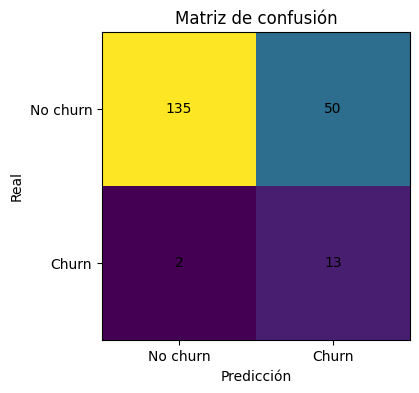

In [ ]:
# Visualización simple
cm = confusion_matrix(y_test, y_pred)
fig = plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")

for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, str(val), ha='center', va='center')

plt.xticks([0,1], ["No churn", "Churn"])
plt.yticks([0,1], ["No churn", "Churn"])
plt.show()


## 7) Tú juegas: mete un cliente y decide

Ejecuta esta celda y prueba distintos perfiles.

**Tip:** cambia una variable cada vez para ver cómo afecta.


In [ ]:
visitas = int(input("Visitas al mes: "))
compras = int(input("Compras históricas: "))
clicks = int(input("Clicks email al mes: "))
antig = int(input("Antigüedad (meses): "))

# Creamos el nuevo cliente como DataFrame
nuevo_cliente = pd.DataFrame([{
    "visitas_mes": visitas,
    "compras_hist": compras,
    "clicks_email_mes": clicks,
    "antiguedad_meses": antig
}])

# Calculamos probabilidad de churn (clase 1)
prob = modelo.predict_proba(nuevo_cliente)[0, 1]

print(f"\nProbabilidad de churn: {prob:.2%}")

Visitas al mes: 100
Compras históricas: 5
Clicks email al mes: 0
Antigüedad (meses): 12

Probabilidad de churn: 0.00%


## 8) Mini reto

Aquí vienen los **3 clientes nuevos**.  
Vuestra misión:

1) Calculad su probabilidad de churn (con el modelo).    
2) Tomad una decisión: **¿darles descuento o no?**  
3) Preparad una mini-justificación (1 frase):  
   - “Actuamos porque…”  
   - “No actuamos porque…”

> Importante: la IA no decide. Decide negocio.  
El modelo solo te da probabilidades y te lleva a pensar en el coste del error.


In [ ]:
clientes_nuevos = pd.DataFrame({
    "cliente": ["G", "H", "I"],
    "visitas_mes": [4, 14, 7],
    "compras_hist": [0, 3, 1],
    "clicks_email_mes": [0, 2, 1],
    "antiguedad_meses": [2, 11, 4]
})
clientes_nuevos


,cliente,visitas_mes,compras_hist,clicks_email_mes,antiguedad_meses
0,G,4,0,0,2
1,H,14,3,2,11
2,I,7,1,1,4


In [ ]:
# Escribe aquí tu respuesta
...

---

## BONUS 🧠 — ¿En qué se basa el modelo para decidir?

En la Regresión Logística, cada variable tiene un **coeficiente** que indica cuánto influye en la probabilidad de churn.

- Coeficiente positivo → aumenta la probabilidad de churn  
- Coeficiente negativo → la reduce  
- Cuanto mayor es el valor (en absoluto), mayor es su impacto  

El modelo no “piensa”.  
Combina variables con distintos pesos y calcula una probabilidad.

La clave es comprobar si esos pesos **tienen sentido para negocio**.  
Si no encajan, hay que revisar datos o modelo.


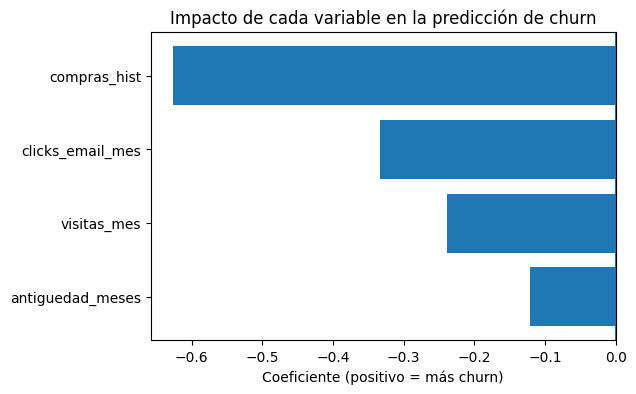

In [ ]:
# Extraemos coeficientes del modelo
coeficientes = pd.DataFrame({
    "variable": X.columns,
    "coeficiente": modelo.coef_[0]
})

# Ordenamos por impacto absoluto
coeficientes["impacto_absoluto"] = coeficientes["coeficiente"].abs()
coeficientes = coeficientes.sort_values("impacto_absoluto", ascending=False)

coeficientes
plt.figure(figsize=(6,4))
plt.barh(coeficientes["variable"], coeficientes["coeficiente"])
plt.axvline(0)
plt.title("Impacto de cada variable en la predicción de churn")
plt.xlabel("Coeficiente (positivo = más churn)")
plt.gca().invert_yaxis()
plt.show()
